# 08 Logistic Regression (TF-IDF)

Notebook to train and evaluate the Logistic Regression with TF-IDF features. This version is an optimized pipeline to run faster and get a higher AUC

## 1. Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Successive Halving
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, train_test_split

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, roc_curve, auc
)

## 2. Load data

In [5]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
test_labels = pd.read_csv('data/test_labels.csv')

categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

## 3. Feature Engineering (Word + Char TF-IDF)

In [6]:
# Word-level TF-IDF
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w+',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=5                            # Ignore words appearing in < 5 comments
)

# Char-level TF-IDF
char_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='char',
    ngram_range=(3, 6),
    max_features=30000,
    min_df=10                           # Ignore char-sequences appearing in < 10 comments
)

In [7]:
X_word = word_vectorizer.fit_transform(train['comment_text'].astype(str))
X_char = char_vectorizer.fit_transform(train['comment_text'].astype(str))

X_train = hstack([X_word, X_char])
y_train = train[categories].values

## 3. Hyperparameter Tuning and model training

L1 regularization helps in high-dimensional spaces by performing feature selection.

Loop with Safety Fallback

In [8]:
final_models = []
best_thresholds = []

In [9]:
for i, category in enumerate(categories):
    print(f"Processing category: {category}")
    y_label = y_train[:, i]
    
    # Check if we have enough samples to even attempt a split
    pos_count = np.sum(y_label)
    
    # SAFETY CHECK: If class is extremely rare, skip tuning and use full data
    if pos_count < 15:
        print(f"Category '{category}' is too rare ({pos_count} samples). Skipping tuning.")
        model = LogisticRegression(solver='saga', C=1.0, class_weight='balanced', max_iter=500)
        model.fit(X_train, y_label)
        final_models.append(model)
        best_thresholds.append(0.5) # Default threshold for ultra-rare
        continue

    try:
        # Attempt Stratified Split
        X_tune, X_val, y_tune, y_val = train_test_split(
            X_train, y_label, test_size=0.7, random_state=42, stratify=y_label
        )

        # Hyperparameter Tuning
        print(f"Tuning hyperparameters")
        base_lr = LogisticRegression(solver='saga', max_iter=500, tol=1e-2)
        param_dist = {'C': [1, 4, 10], 'penalty': ['l1', 'l2'], 'class_weight': [None, 'balanced']}
        
        search = HalvingRandomSearchCV(base_lr, param_dist, factor=3, scoring='roc_auc', n_jobs=-1, random_state=42)
        search.fit(X_tune, y_tune)
        model = search.best_estimator_
        
        # Final Fit on Full Data
        print(f"Training final model")
        model.fit(X_train, y_label)
        final_models.append(model)
        
        # Optimize Threshold
        y_prob_val = model.predict_proba(X_val)[:, 1]
        precision, recall, thresholds = precision_recall_curve(y_val, y_prob_val)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        best_threshold = thresholds[np.argmax(f1_scores)]
        best_thresholds.append(best_threshold)
        print(f"""
                C: {search.best_params_['C']} 
                Threshold: {best_threshold:.2f}
                """)

    except ValueError:
        # EMERGENCY FALLBACK: If tuning still fails
        print(f"Tuning failed for {category} due to class distribution. Using fallback.")
        model = LogisticRegression(solver='saga', class_weight='balanced', max_iter=500)
        model.fit(X_train, y_label)
        final_models.append(model)
        best_thresholds.append(0.5)

Processing category: toxic
Tuning hyperparameters


Training final model


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



                C: 10 
                Threshold: 0.78
                
Processing category: severe_toxic
Tuning hyperparameters


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 12 is smaller than n_iter=2393. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


...


                C: 10 
                Threshold: 0.82
                
Processing category: identity_hate
Tuning hyperparameters


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 12 is smaller than n_iter=2393. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator,

Training final model


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



                C: 10 
                Threshold: 1.00
                


## 4 Evaluation

In [10]:
test_combined = pd.merge(test, test_labels, on='id')
test_scored = test_combined[test_combined['toxic'] != -1].copy()

X_test_word = word_vectorizer.transform(test_scored['comment_text'].astype(str))
X_test_char = char_vectorizer.transform(test_scored['comment_text'].astype(str))
X_test = hstack([X_test_word, X_test_char])
y_test = test_scored[categories].values

y_prob = np.column_stack([m.predict_proba(X_test)[:, 1] for m in final_models])
y_pred = np.zeros_like(y_prob)

## 5 Results

In [11]:
for i in range(len(categories)):
    y_pred[:, i] = (y_prob[:, i] >= best_thresholds[i]).astype(int)

In [16]:
metrics_list = []

for i, category in enumerate(categories):
    metrics_list.append({
        'Category': category,
        'Accuracy': accuracy_score(y_test[:, i], y_pred[:, i]),
        'Precision': precision_score(y_test[:, i], y_pred[:, i], zero_division=0),
        'Recall': recall_score(y_test[:, i], y_pred[:, i], zero_division=0),
        'F1-Score': f1_score(y_test[:, i], y_pred[:, i], zero_division=0),
        'AUC': roc_auc_score(y_test[:, i], y_prob[:, i])
    })

In [17]:
pd.DataFrame(metrics_list).round(4)

,Category,Accuracy,Precision,Recall,F1-Score,AUC
0,toxic,0.9175,0.5436,0.8294,0.6567,0.9591
1,severe_toxic,0.9887,0.2605,0.5232,0.3478,0.9820
2,obscene,0.9607,0.6428,0.7188,0.6787,0.9618
3,threat,0.7994,0.0160,0.9858,0.0314,0.9700
4,insult,0.9551,0.5644,0.7105,0.6291,0.9602
5,identity_hate,0.9879,0.4617,0.5169,0.4877,0.9632


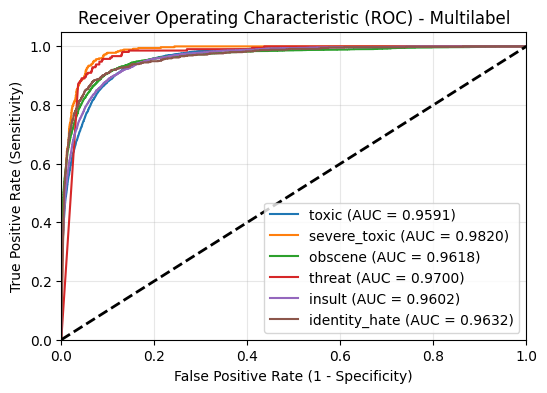

In [22]:
# 1. Create a figure
plt.figure(figsize=(6, 4))

# 2. Loop through each category to calculate and plot the curve
for i, category in enumerate(categories):
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve for this specific category
    plt.plot(fpr, tpr, label=f'{category} (AUC = {roc_auc:.4f})')

# 3. Plot the diagonal line (random guessing baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# 4. Formatting the graph
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Multilabel')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 6 save the model

In [14]:
import joblib

In [15]:
# Save to file
joblib.dump(model, "model.pkl")

['model.pkl']

## 7 Generate csv for submission

In [23]:
X_sub_word = word_vectorizer.transform(test['comment_text'].astype(str))
X_sub_char = char_vectorizer.transform(test['comment_text'].astype(str))
X_sub = hstack([X_sub_word, X_sub_char])

In [24]:
# Get probabilities for each category
y_sub_prob = np.column_stack([
    model.predict_proba(X_sub)[:, 1] for model in final_models
])

In [27]:
submission = pd.DataFrame(y_sub_prob, columns=categories)
submission = submission.round(3)
submission.insert(0, 'id', test['id'])

In [28]:
submission.to_csv('submission.csv', index=False)

End of notebook